# Black-Scholes Option Pricer with Greeks and Monte Carlo

Pricing European options two ways - the closed-form **Black-Scholes** solution and **Monte Carlo** simulation - and computing the full set of **Greeks** (Δ, Γ, Vega, Θ, ρ) from their analytical formulas.

The goal is to implement everything *from the underlying mathematics* rather than wrapping a library, and to validate the two approaches against each other.

## The model

Under the risk-neutral measure, the underlying follows a geometric Brownian motion:

$$dS_t = r S_t\,dt + \sigma S_t\,dW_t$$

The price of a European call is the discounted expected payoff:

$$C = e^{-rT}\,\mathbb{E}^{\mathbb{Q}}[\max(S_T - K,\,0)]$$

which admits the closed-form Black-Scholes solution derived below.

In [1]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

## 1. The Black-Scholes closed-form price

For a European option, the price has a closed-form solution:

$$C = S_0\,N(d_1) - K e^{-rT} N(d_2) \qquad P = K e^{-rT} N(-d_2) - S_0 N(-d_1)$$

where

$$d_1 = \frac{\ln(S_0/K) + (r + \sigma^2/2)\,T}{\sigma\sqrt{T}}, \qquad d_2 = d_1 - \sigma\sqrt{T}$$

Intuition: $N(d_2)$ is the risk-neutral probability the option finishes in-the-money, and $S_0 N(d_1)$ is the expected value of the asset received, conditional on exercise.

In [5]:
def BlackScholesPrice(S, K, T, r, sigma, option_type="call"):
    """
    Closed-form Black-Scholes price for a European option.

    Parameters
    ----------
    S : float   - current price of the underlying
    K : float   - strike price
    T : float   - time to maturity, in years
    r : float   - risk-free rate (annualized, continuous)
    sigma : float - volatility (annualized)
    option_type : str - "call" or "put"

    Returns
    -------
    float : option price
    """

    # Guard against the degenerate T=0 case
    if T <= 0:
        if option_type == "call":
            return max(S - K, 0.0)
        else:
            return max(K - S, 0.0)

    d1 = (np.log(S/K) + T*(r + (sigma**2)/2)) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)

    if option_type == "call":
        price = S*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)
    elif option_type == "put":
        price = K*np.exp(-r*T)*norm.cdf(-d2) - S*norm.cdf(-d1)
    else:
        raise ValueError("option_type must be 'call' or 'put'")

    return price

## 2. The Greeks

The Greeks are the partial derivatives of the option price — they measure how the price responds to each input, and they are the foundation of hedging. For a European call:

$$\Delta = N(d_1) \qquad \Gamma = \frac{N'(d_1)}{S\sigma\sqrt{T}} \qquad \mathcal{V} = S\,N'(d_1)\sqrt{T}$$

$$\Theta = -\frac{S\,N'(d_1)\sigma}{2\sqrt{T}} - rKe^{-rT}N(d_2) \qquad \rho = KTe^{-rT}N(d_2)$$

where $N'(x)$ is the standard normal **density**. Δ and Γ are the option's "velocity" and "acceleration" with respect to the underlying.

In [12]:
def Greeks(S, K, T, r, sigma, option_type="call"):
    """
    Analytical Greeks for a European option under Black-Scholes.

    Returns
    -------
    dict with keys: delta, gamma, vega, theta, rho
      - vega is per 1.00 change in sigma (divide by 100 for per-1%-point)
      - theta is per year (divide by 365 for per-calendar-day)
    """
    if T <= 0:
        raise ValueError("Greeks are undefined at T=0")

    d1 = (np.log(S/K) + T*(r + (sigma**2)/2)) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)

    pdf_d1 = norm.pdf(d1)

    # Gamma and Vega are identical for calls and puts
    gamma = pdf_d1 / (S*sigma*np.sqrt(T))
    vega = S*pdf_d1*np.sqrt(T)

    if option_type == "call":
        delta = norm.cdf(d1)
        theta = -(S*pdf_d1*sigma) / (2*np.sqrt(T)) - r*K*np.exp(-r*T)*norm.cdf(d2)
        rho = K*T*np.exp(-r*T)*norm.cdf(d2)
    elif option_type == "put":
        delta = norm.cdf(d1) - 1
        theta = -(S*pdf_d1*sigma) / (2*np.sqrt(T)) - r*K*np.exp(-r*T)*norm.cdf(-d2)
        rho = -K*T*np.exp(-r*T)*norm.cdf(-d2)
    else:
        raise ValueError("option_type must be 'call' or 'put'")

    return {"delta": delta, "gamma": gamma, "vega": vega, "theta": theta, "rho": rho}

## 3. Monte Carlo pricing

Instead of the closed form, we can price by simulation. Under the risk-neutral measure we simulate many terminal prices of the underlying:

$$S_T^{(i)} = S_0 \exp\left[\left(r - \tfrac{1}{2}\sigma^2\right)T + \sigma\sqrt{T}\,Z_i\right], \quad Z_i \sim \mathcal{N}(0,1)$$

and average the discounted payoff:

$$\hat{C} = e^{-rT}\,\frac{1}{M}\sum_{i=1}^{M}\max(S_T^{(i)} - K,\,0)$$

The estimator's error decays as $\mathcal{O}(1/\sqrt{M})$. We use **antithetic variates** (pairing each $Z_i$ with $-Z_i$) to reduce variance at no extra cost.

In [17]:
def MonteCarloPrice(S, K, T, r, sigma, option_type="call", n_sims=100000, antithetic=True, seed=None):
    """
    Monte Carlo price for a European option under geometric Brownian motion.

    Parameters
    ----------
    n_sims : number of simulated terminal prices
    antithetic : if True, use antithetic variates for variance reduction
    seed : random seed for reproducibility

    Returns
    -------
    dict with keys: price, std_error
    """

    rng = np.random.default_rng(seed)

    if antithetic:
        # Generate half the draws, then mirror them: Z and -Z
        half = n_sims//2
        Z_half = rng.standard_normal(half)
        Z = np.concatenate([Z_half, -Z_half])
    else:
        Z = rng.standard_normal(n_sims)

    # Simulate terminal prices using the exact Geometric Brownian Motion solution
    drift = T*(r - (sigma**2)/2)
    diffusion = sigma*np.sqrt(T)*Z

    S_T = S*np.exp(drift + diffusion)

    # Payoff at maturity
    if option_type == "call":
        payoffs = np.maximum(S_T - K, 0.0)
    elif option_type == "put":
        payoffs = np.maximum(K - S_T, 0.0)
    else:
        raise ValueError("option_type must be 'call' or 'put'")

    # Discounted price back to today
    discounted = payoffs * np.exp(-r*T)

    price = discounted.mean()
    std_error = discounted.std(ddof=1) / np.sqrt(len(discounted))

    return {"price": price, "std_error": std_error}

In [18]:
# Price the same option both ways and compare
bs_call = BlackScholesPrice(S0, K, T, r, sigma, "call")
mc_call = MonteCarloPrice(S0, K, T, r, sigma, "call",
                            n_sims=100_000, antithetic=True, seed=42)

print("European Call — Black-Scholes vs Monte Carlo")
print(f"  Black-Scholes (exact):  {bs_call:.4f}")
print(f"  Monte Carlo (estimate): {mc_call['price']:.4f} ± {mc_call['std_error']:.4f}")

# Is the analytical price within the MC confidence interval?
diff = abs(bs_call - mc_call['price'])
within_2se = diff < 2 * mc_call['std_error']
print(f"\n  Difference: {diff:.4f}")
print(f"  Within 2 standard errors: {within_2se}")

European Call — Black-Scholes vs Monte Carlo
  Black-Scholes (exact):  10.4506
  Monte Carlo (estimate): 10.4673 ± 0.0467

  Difference: 0.0167
  Within 2 standard errors: True


## 4. Convergence of Monte Carlo to the analytical price

As the number of simulations grows, the Monte Carlo estimate should converge to the Black-Scholes price, with the error shrinking as $1/\sqrt{M}$. We visualize this — and show how antithetic variates tighten the estimate.

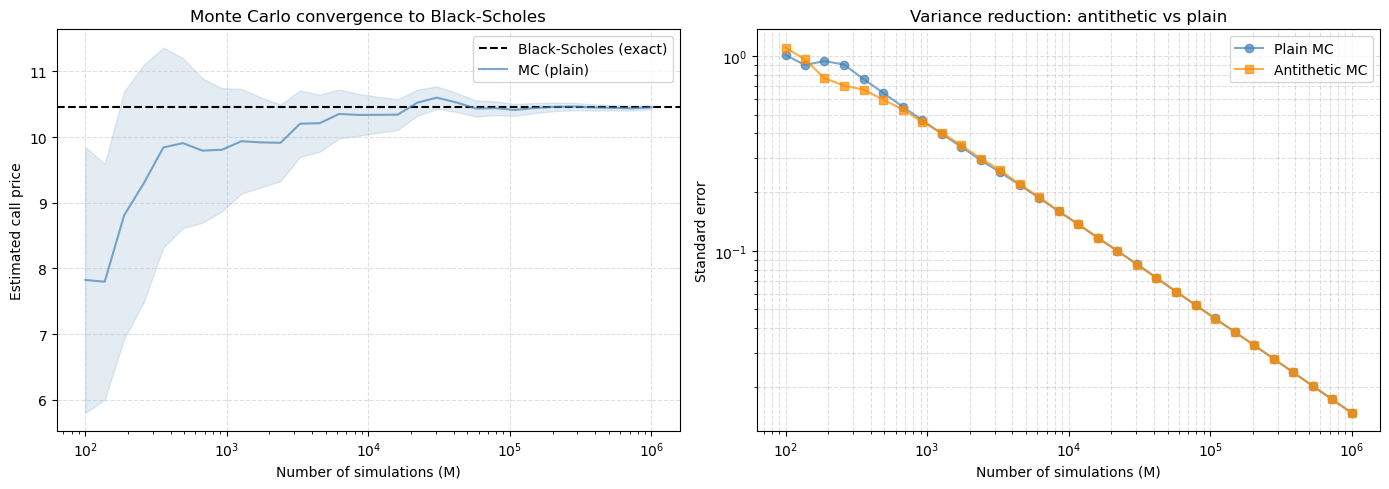

In [21]:
# Range of simulation counts to test
sim_counts = np.logspace(2, 6, 30).astype(int)  # from 100 to 1,000,000

prices_plain = []
prices_anti = []
errors_plain = []
errors_anti = []

for n in sim_counts:
    mc_p = MonteCarloPrice(S0, K, T, r, sigma, "call",
                             n_sims=n, antithetic=False, seed=42)
    mc_a = MonteCarloPrice(S0, K, T, r, sigma, "call",
                             n_sims=n, antithetic=True, seed=42)
    prices_plain.append(mc_p["price"])
    prices_anti.append(mc_a["price"])
    errors_plain.append(mc_p["std_error"])
    errors_anti.append(mc_a["std_error"])

prices_plain = np.array(prices_plain)
prices_anti = np.array(prices_anti)
errors_plain = np.array(errors_plain)
errors_anti = np.array(errors_anti)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: price convergence with error bands
ax1.axhline(bs_call, color="black", linestyle="--", label="Black-Scholes (exact)")
ax1.plot(sim_counts, prices_plain, color="steelblue", alpha=0.7, label="MC (plain)")
ax1.fill_between(sim_counts, prices_plain - 2*errors_plain,
                 prices_plain + 2*errors_plain, color="steelblue", alpha=0.15)
ax1.set_xscale("log")
ax1.set_xlabel("Number of simulations (M)")
ax1.set_ylabel("Estimated call price")
ax1.set_title("Monte Carlo convergence to Black-Scholes")
ax1.legend()
ax1.grid(True, linestyle="--", alpha=0.4)

# Right: standard error decay, plain vs antithetic
ax2.loglog(sim_counts, errors_plain, "o-", color="steelblue",
           alpha=0.7, label="Plain MC")
ax2.loglog(sim_counts, errors_anti, "s-", color="darkorange",
           alpha=0.7, label="Antithetic MC")
ax2.set_xlabel("Number of simulations (M)")
ax2.set_ylabel("Standard error")
ax2.set_title("Variance reduction: antithetic vs plain")
ax2.legend()
ax2.grid(True, linestyle="--", alpha=0.4, which="both")

plt.tight_layout()
plt.show()

## 5. Visualizing price and Greeks

The closed-form solutions let us plot how the option value and its sensitivities behave across a range of underlying prices. These shapes are the intuition behind hedging.

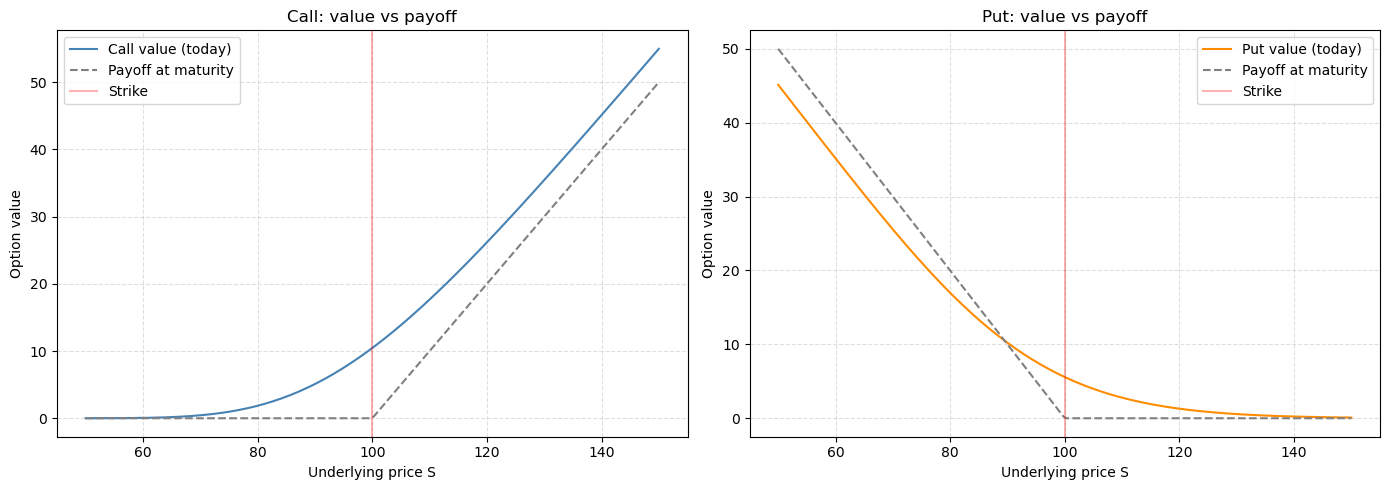

In [23]:
# Range of underlying prices to sweep
S_range = np.linspace(50, 150, 200)

call_prices = [BlackScholesPrice(s, K, T, r, sigma, "call") for s in S_range]
put_prices  = [BlackScholesPrice(s, K, T, r, sigma, "put")  for s in S_range]

# Payoff at maturity (intrinsic value) for reference
call_payoff = np.maximum(S_range - K, 0)
put_payoff  = np.maximum(K - S_range, 0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(S_range, call_prices, color="steelblue", label="Call value (today)")
ax1.plot(S_range, call_payoff, color="gray", linestyle="--", label="Payoff at maturity")
ax1.axvline(K, color="red", alpha=0.3, label="Strike")
ax1.set_xlabel("Underlying price S")
ax1.set_ylabel("Option value")
ax1.set_title("Call: value vs payoff")
ax1.legend()
ax1.grid(True, linestyle="--", alpha=0.4)

ax2.plot(S_range, put_prices, color="darkorange", label="Put value (today)")
ax2.plot(S_range, put_payoff, color="gray", linestyle="--", label="Payoff at maturity")
ax2.axvline(K, color="red", alpha=0.3, label="Strike")
ax2.set_xlabel("Underlying price S")
ax2.set_ylabel("Option value")
ax2.set_title("Put: value vs payoff")
ax2.legend()
ax2.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

/tmp/ipykernel_6134/1700971569.py:28: UserWarning: Glyph 119985 (\N{MATHEMATICAL SCRIPT CAPITAL V}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/bobby/miniconda3/envs/dataenv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 119985 (\N{MATHEMATICAL SCRIPT CAPITAL V}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


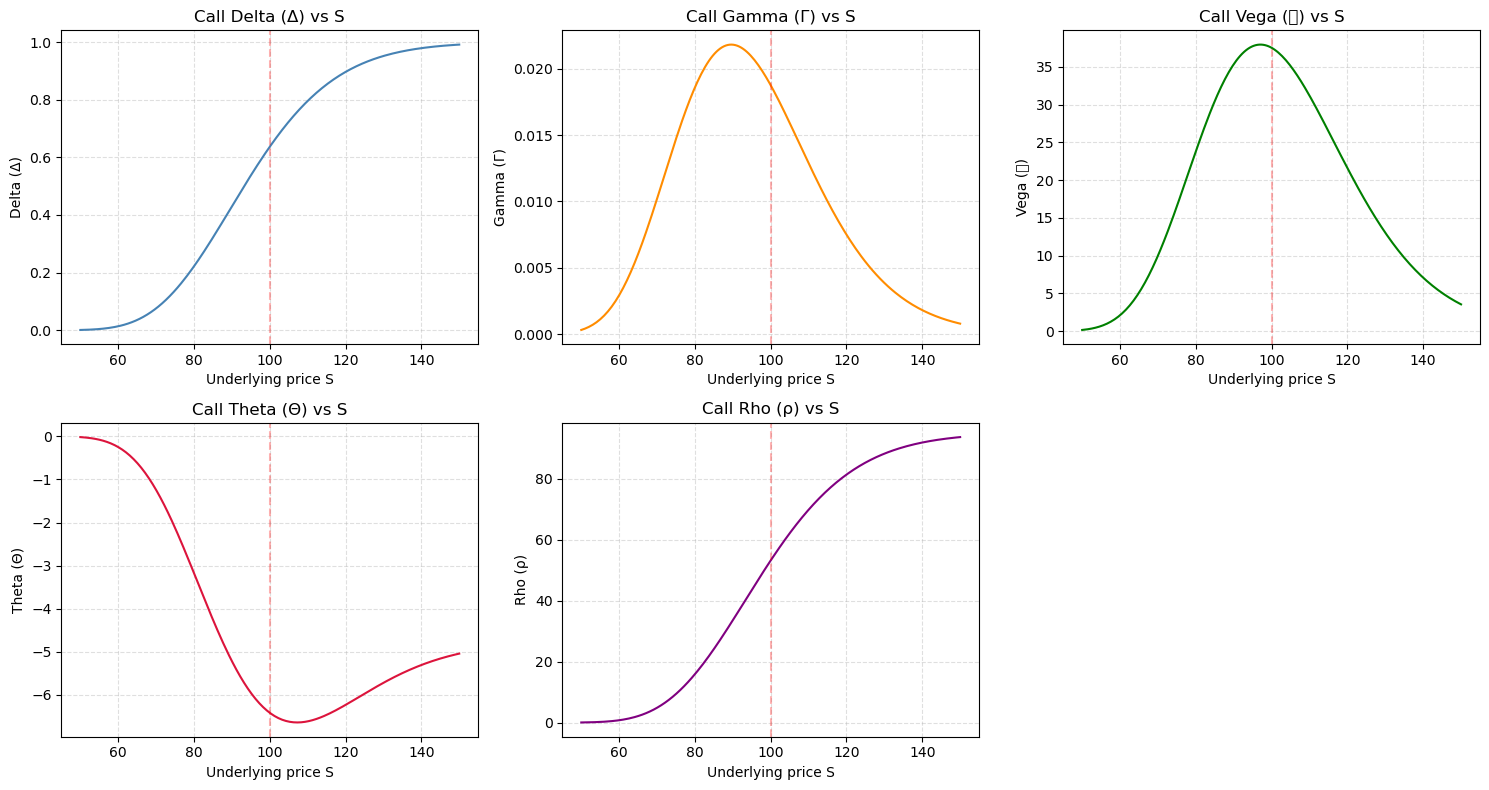

In [25]:
# Compute each Greek across the range of underlying prices
deltas = [Greeks(s, K, T, r, sigma, "call")["delta"] for s in S_range]
gammas = [Greeks(s, K, T, r, sigma, "call")["gamma"] for s in S_range]
vegas  = [Greeks(s, K, T, r, sigma, "call")["vega"]  for s in S_range]
thetas = [Greeks(s, K, T, r, sigma, "call")["theta"] for s in S_range]
rhos   = [Greeks(s, K, T, r, sigma, "call")["rho"]   for s in S_range]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
greeks_data = [
    ("Delta (Δ)", deltas, "steelblue"),
    ("Gamma (Γ)", gammas, "darkorange"),
    ("Vega (𝒱)", vegas, "green"),
    ("Theta (Θ)", thetas, "crimson"),
    ("Rho (ρ)", rhos, "purple"),
]

for ax, (name, data, color) in zip(axes.flat, greeks_data):
    ax.plot(S_range, data, color=color)
    ax.axvline(K, color="red", alpha=0.3, linestyle="--")
    ax.set_xlabel("Underlying price S")
    ax.set_ylabel(name)
    ax.set_title(f"Call {name} vs S")
    ax.grid(True, linestyle="--", alpha=0.4)

# Hide the unused 6th subplot
axes.flat[5].axis("off")

plt.tight_layout()
plt.show()